🚕 Uber Rides Data Analysis – New York (2016)
📊 Exploring Business Mobility Trends and Travel Behavior

This project analyzes 1,155 Uber trips recorded throughout 2016, focusing on travel purpose, temporal patterns, mileage, and location-based insights to support data-driven recommendations for operational efficiency and cost optimization.

In [2]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#importing the dataset
dataset = pd.read_csv('uber-rides-2016.csv')
dataset.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


Inspecting data set

In [5]:
dataset.shape

(1156, 7)

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [9]:
dataset.describe()

,MILES*
count,1156.000000
mean,21.115398
std,359.299007
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,12204.700000


Observations:

*The dataset contains a few missing values in multiple columns (notably 43% of PURPOSE* values).
*MILES* values vary significantly — likely due to some long intercity trips.
*Dates are currently stored as strings (object type), so they’ll need conversion to datetime for time-based analysis.
*Column names contain * characters — it’ll be cleaner to rename them

Next Step: Data cleaning and preparation

In [11]:
#rename columns to remove * characters
dataset.columns = [col.replace('*', '') for col in dataset.columns]
dataset.head(2)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN


Handling missing values

In [13]:
#checking for missing values
dataset.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [14]:
#drop rows with missing critical values
dataset = dataset.dropna(subset=['START_DATE','END_DATE','START','STOP','MILES'])
dataset.isnull().sum()

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

In [ ]:
#replacing missing PURPOSE values with 'Unknown'
dataset['PURPOSE'] = dataset['PURPOSE'].fillna('Unknown')
dataset.isnull().sum()

C:\Users\Manuj\AppData\Local\Temp\ipykernel_77788\2457281034.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['PURPOSE'] = dataset['PURPOSE'].fillna('Unknown')


START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

converting dates and feature extraction

In [68]:
#converting date columns to datetime
dataset.loc[:,'START_DATE'] = pd.to_datetime(dataset['START_DATE'],errors='coerce')
dataset.loc[:,'END_DATE'] = pd.to_datetime(dataset['END_DATE'],errors='coerce')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1154
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   START_DATE       1155 non-null   datetime64[ns]
 1   END_DATE         1155 non-null   datetime64[ns]
 2   CATEGORY         1155 non-null   object        
 3   START            1155 non-null   object        
 4   STOP             1155 non-null   object        
 5   MILES            1155 non-null   float64       
 6   PURPOSE          1155 non-null   object        
 7   START_HOUR       1155 non-null   int32         
 8   START_DAY        1155 non-null   int32         
 9   START_MONTH      1155 non-null   int32         
 10  START_DATE_ONLY  1155 non-null   object        
 11  START_WEEKDAY    1155 non-null   object        
 12  ROUTE            1155 non-null   object        
 13  DURATION_MINS    1155 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int32(3), o

In [18]:
#extracting time-based features
dataset.loc[:,'START_HOUR'] = dataset['START_DATE'].dt.hour
dataset.loc[:,'START_DAY'] = dataset['START_DATE'].dt.day
dataset.loc[:,'START_MONTH'] = dataset['START_DATE'].dt.month
dataset.loc[:,'START_DATE_ONLY'] = dataset['START_DATE'].dt.date
dataset.head(2)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,START_HOUR,START_DAY,START_MONTH,START_DATE_ONLY
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,1,1,2016-01-01
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Unknown,1,2,1,2016-01-02


Exploratory data analysis

In [20]:
#basic statistics
print("Total Rides:", len(dataset))
print("Total Miles:", dataset['MILES'].sum())
print("Average Miles per Ride:", dataset['MILES'].mean())
print("\nCategory distribution:")
print(dataset['CATEGORY'].value_counts())
print("\nPurpose distribution (Top 10):")
print(dataset['PURPOSE'].value_counts().head(10))

Total Rides: 1155
Total Miles: 12204.7
Average Miles per Ride: 10.566839826839827

Category distribution:
CATEGORY
Business    1078
Personal      77
Name: count, dtype: int64

Purpose distribution (Top 10):
PURPOSE
Unknown            502
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Temporary Site      50
Between Offices     18
Moving               4
Airport/Travel       3
Commute              1
Name: count, dtype: int64


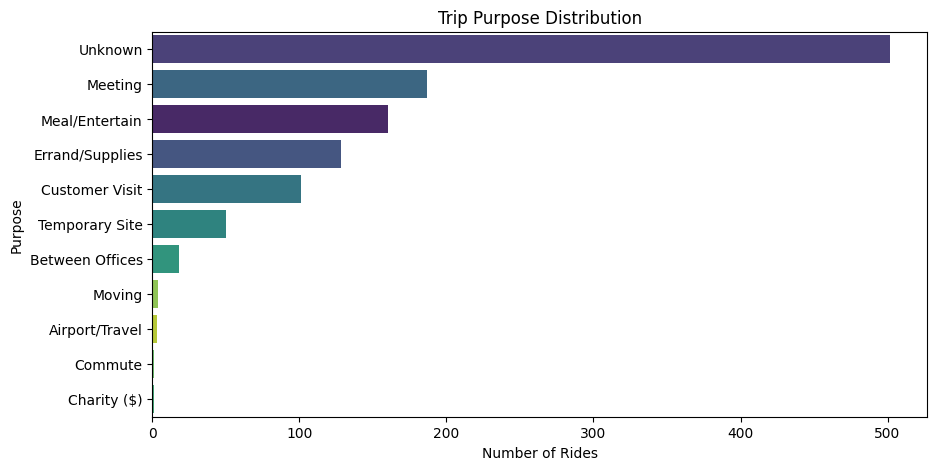

In [27]:
#trip purpose distribution
plt.figure(figsize=(10,5))
sns.countplot(data=dataset, y='PURPOSE', hue='PURPOSE', legend=False, order=dataset['PURPOSE'].value_counts().index, palette='viridis')
plt.title('Trip Purpose Distribution')
plt.xlabel('Number of Rides')
plt.ylabel('Purpose')
plt.show()

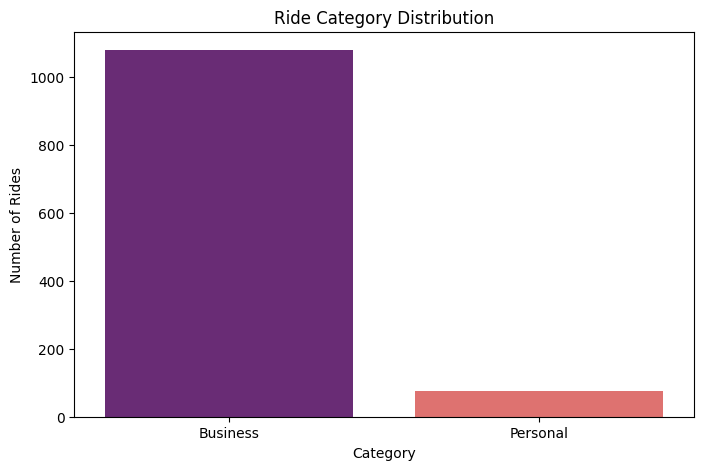

In [36]:
#category distribution
category_counts = dataset['CATEGORY'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index, hue=category_counts.index, legend=False, y=category_counts.values, palette='magma')
plt.title('Ride Category Distribution') 
plt.xlabel('Category')
plt.ylabel('Number of Rides')
plt.show()

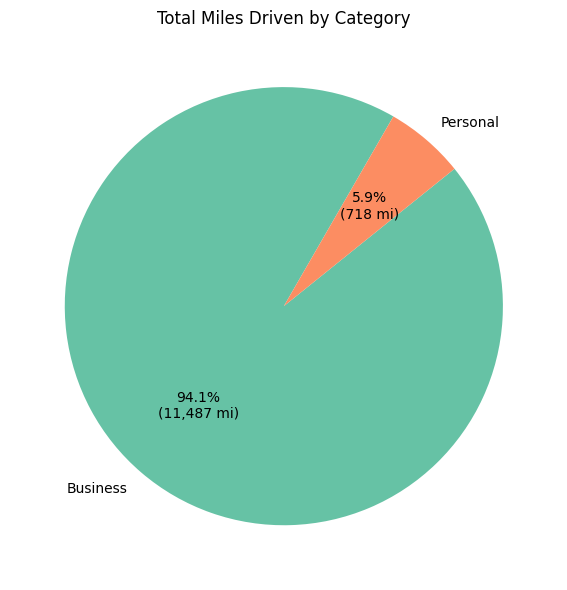

Category Miles Distribution: CATEGORY
Business    11487.0
Personal      717.7
Name: MILES, dtype: float64


In [51]:
#category miles distribution
category_miles = dataset.groupby('CATEGORY')['MILES'].sum().sort_values(ascending=False)

# Custom label formatter to show both miles & percentage
def miles_pct_label(pct, allvals):
    absolute = int(round(pct/100. * sum(allvals)))
    return f"{pct:.1f}%\n({absolute:,} mi)"

plt.figure(figsize=(6,6))
plt.pie(
    category_miles,
    labels=category_miles.index,
    autopct=lambda pct: miles_pct_label(pct, category_miles.values),
    startangle=60,
    colors=sns.color_palette('Set2')
)

plt.title('Total Miles Driven by Category')
plt.ylabel('')
plt.tight_layout()
plt.show()

print("Category Miles Distribution:", category_miles)


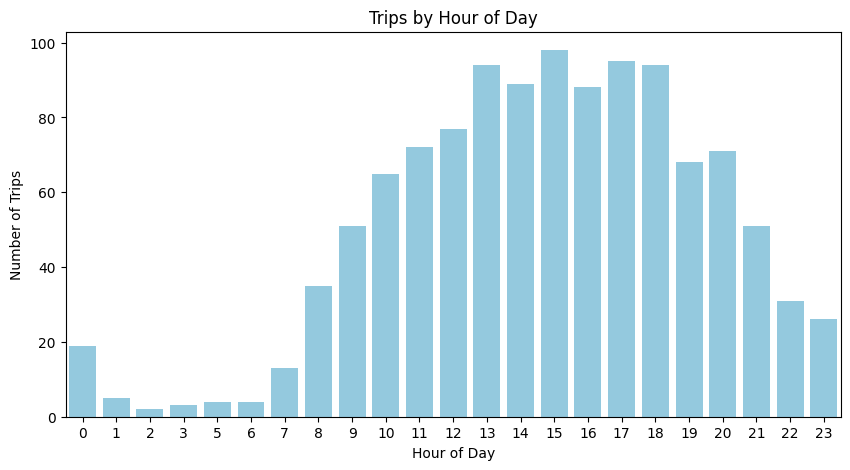

In [ ]:
#trip distribution by hour
plt.figure(figsize=(10,5))
sns.countplot(x='START_HOUR', data=dataset, color='skyblue')
plt.title('Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0,24))
plt.show()

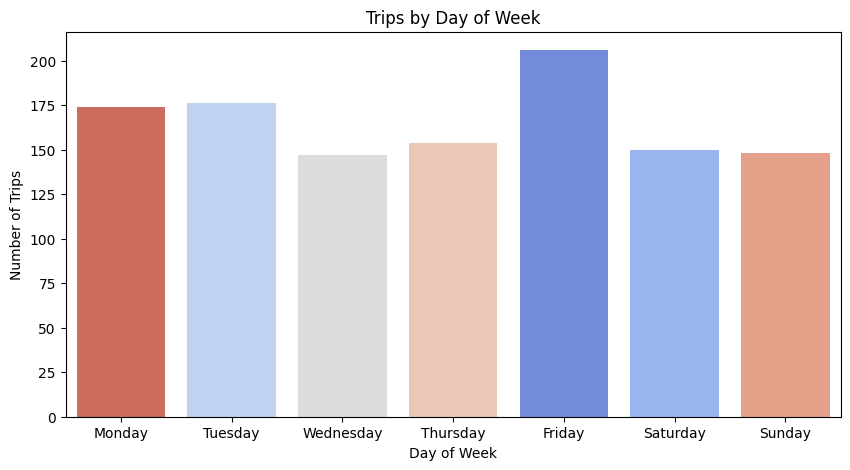

In [69]:
#trips by day
dataset.loc[:,'START_WEEKDAY'] = dataset['START_DATE'].dt.day_name()

plt.figure(figsize=(10,5))
sns.countplot(x='START_WEEKDAY', hue='START_WEEKDAY', legend=False,data=dataset,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
              palette='coolwarm')
plt.title('Trips by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.show()

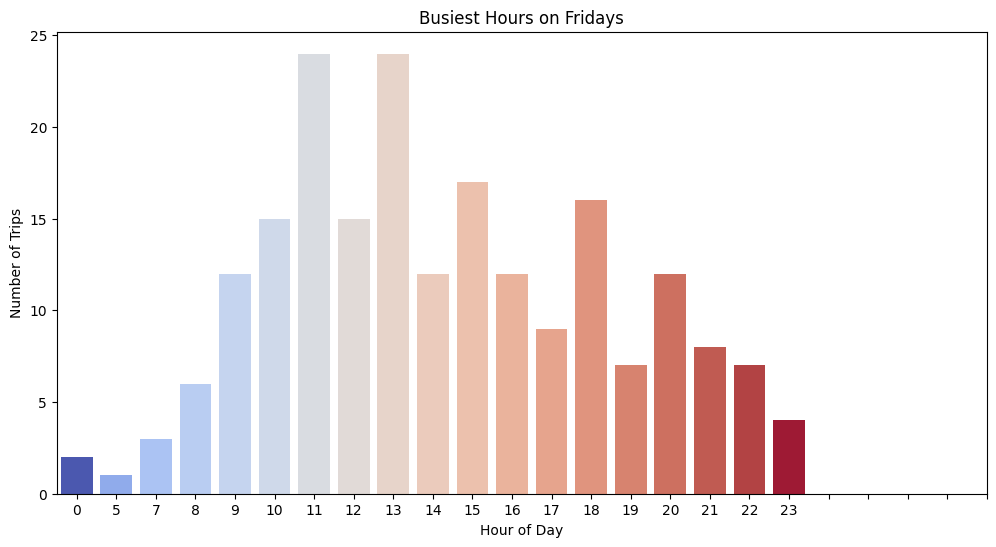

START_HOUR
0      2
5      1
7      3
8      6
9     12
10    15
11    24
12    15
13    24
14    12
15    17
16    12
17     9
18    16
19     7
20    12
21     8
22     7
23     4
Name: count, dtype: int64


In [67]:
# Filter Friday trips
friday_data = dataset[dataset['START_WEEKDAY'] == 'Friday']

# Count trips by hour on Friday
friday_hourly = friday_data['START_HOUR'].value_counts().sort_index()

plt.figure(figsize=(12,6))
sns.barplot(x=friday_hourly.index, hue=friday_hourly.index, legend=False, y=friday_hourly.values, palette='coolwarm')
plt.title('Busiest Hours on Fridays')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0,24))
plt.show()

print(friday_hourly)

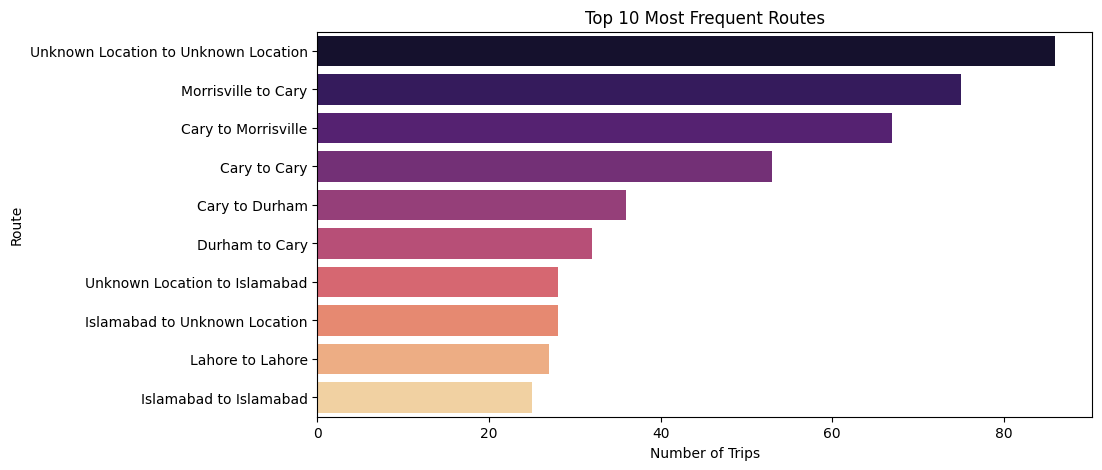

In [70]:
#mostfrequent routes
dataset.loc[:,'ROUTE'] = dataset['START'] + " to " + dataset['STOP']
top_routes = dataset['ROUTE'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(y=top_routes.index, x=top_routes.values, hue=top_routes.index, legend=False,palette='magma')
plt.title('Top 10 Most Frequent Routes')
plt.xlabel('Number of Trips')
plt.ylabel('Route')
plt.show()

Top Starting Locations:
 START
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               37
Lahore               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64


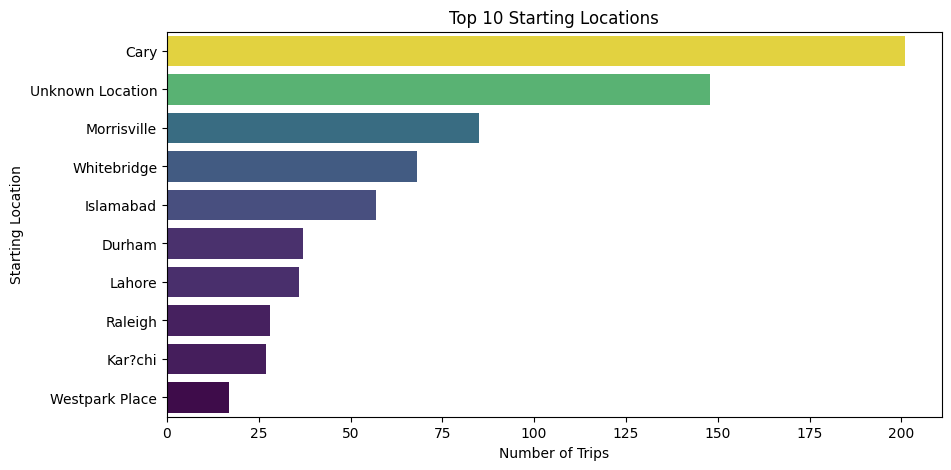

In [62]:
top_starting_locations = dataset['START'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(y=top_starting_locations.index, hue=top_starting_locations, legend=False, x=top_starting_locations.values, palette='viridis')
plt.title('Top 10 Starting Locations')
plt.xlabel('Number of Trips')
plt.ylabel('Starting Location') 

print("Top Starting Locations:\n", top_starting_locations)

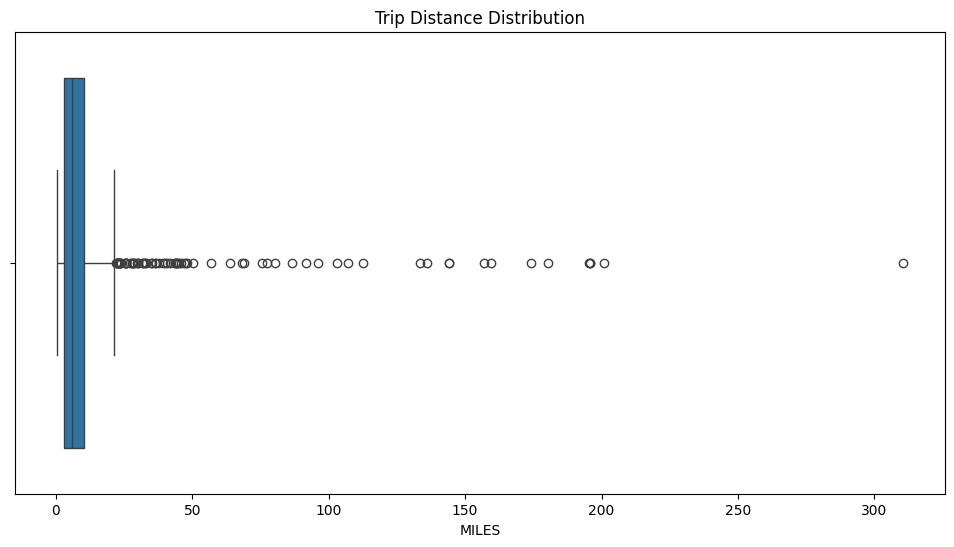

In [59]:
plt.figure(figsize=(12,6))
sns.boxplot(x=dataset['MILES'])
plt.title('Trip Distance Distribution')
plt.show()

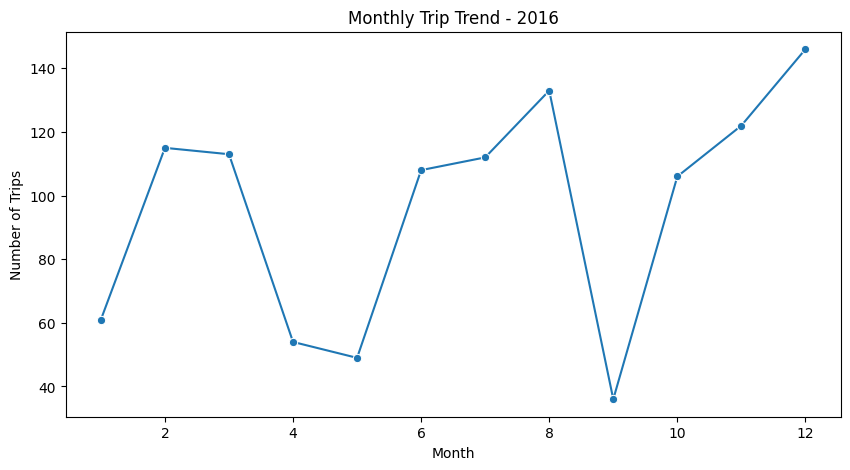

In [63]:
#monthly rides trend
monthly_trips = dataset['START_MONTH'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_trips.index, y=monthly_trips.values, marker='o')
plt.title("Monthly Trip Trend - 2016")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.show()

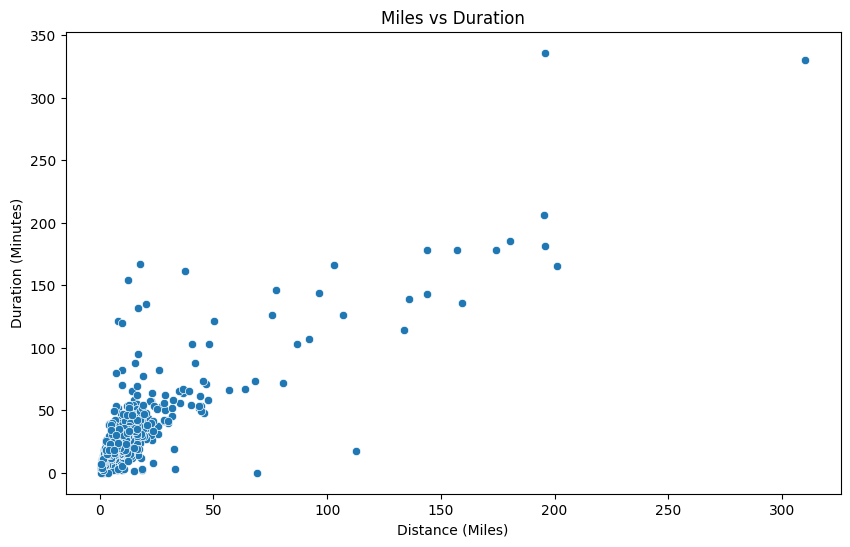

In [65]:
#distance vs duration
dataset.loc[:,'DURATION_MINS'] = (dataset['END_DATE'] - dataset['START_DATE']).dt.total_seconds() / 60

plt.figure(figsize=(10,6))
sns.scatterplot(x='MILES', y='DURATION_MINS', data=dataset)
plt.title('Miles vs Duration')
plt.xlabel('Distance (Miles)')
plt.ylabel('Duration (Minutes)')
plt.show()

🏁 Final Summary & Insights

This analysis explores 1,155 Uber rides recorded in 2016, including trip start/end times, locations, distance traveled, and trip purpose. The objective was to gain insights into travel behavior, business mobility patterns, and potential opportunities for cost and operational optimization.

🔑 Key Findings
1️⃣ Business Usage Dominates

93% of rides were recorded as Business trips.

94% of total miles (11,487 mi) were business-related.

Corporate mobility relies heavily on ride-hailing services.

2️⃣ Purpose Patterns

Nearly 43% of trips had no stated purpose → Data compliance issue

Among known purposes:

Meetings (187 trips) most common

Meal/Entertainment and Errands/Supplies follow closely

Activity reflects typical corporate workflow and field operations

3️⃣ Temporal Demand Trends

Friday is the busiest day (~209 trips)

Peak ride demand occurs between 11 AM – 2 PM on Fridays

Driven by meetings and mid-day business movements

Weekdays are consistently busier than weekends

Very little late-night activity → rides are not leisure-oriented

4️⃣ Travel Distance & Duration

Majority of rides are short-distance urban trips (<20 miles)

Several long-distance outliers (200–300+ miles)

Likely airport or inter-city travel

Recommend further categorization or cost review

5️⃣ Top Locations & Routes

Most trips originate from Cary, Morrisville, and Whitebridge region

Some location names unclear (e.g., “Unknown Location”)

Suggests opportunity for improved data entry and standardization


📌 Business Implications

Allocation of more drivers on peak days(mainly Friday)

Drivers can choose busy hours of the day for better revenue generation

Ensuring availability of sufficient drivers in starting locations with higher demand(Cary, Morrisville)

Other business can reduce corporate travel costs possible by avoiding Friday peak hours (11 AM–2 PM)


